# Session 03: Image Filtering & Frequency Analysis

**CVI4IC — Summer Semester 2026**

Topics: convolution, Gaussian filter, border handling, Fourier transform, frequency-domain filtering, and hybrid images.

In [2]:
# !pip install -q opencv-python-headless matplotlib numpy scikit-image

import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os

In [3]:
!git clone --depth 1 https://github.com/fruits-360/fruits-360-100x100.git 2>/dev/null || echo "Dataset already cloned."

DATASET_ROOT = Path("fruits-360-100x100")
TRAIN_DIR = DATASET_ROOT / "Training"
TEST_DIR = DATASET_ROOT / "Test"

classes = sorted(os.listdir(TRAIN_DIR))
print(f"Fruits-360: {len(classes)} classes")

def load_fruit(class_name, index=0):
    """Load a single fruit image as BGR numpy array."""
    cls_dir = TRAIN_DIR / class_name
    return cv2.imread(str(sorted(cls_dir.glob("*.jpg"))[index]))

def to_rgb(img_bgr):
    return cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

def to_gray(img_bgr):
    return cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

"Dataset already cloned."
Fruits-360: 251 classes


The system cannot find the path specified.


## 1. Convolution — The Core Operation

A **linear filter** (convolution) replaces each pixel with a weighted sum of its neighbours:

$$g(x, y) = \sum_{i=-k}^{k} \sum_{j=-k}^{k} h(i, j) \cdot f(x - i, y - j)$$

where $h$ is the **kernel** (filter mask) of size $(2k+1) \times (2k+1)$.

In OpenCV any kernel can be applied with `cv2.filter2D(img, -1, kernel)`.

### 1.1 Average (Box) Filter

The simplest filter: every weight is equal. Replaces each pixel with the **mean** of its neighbourhood.

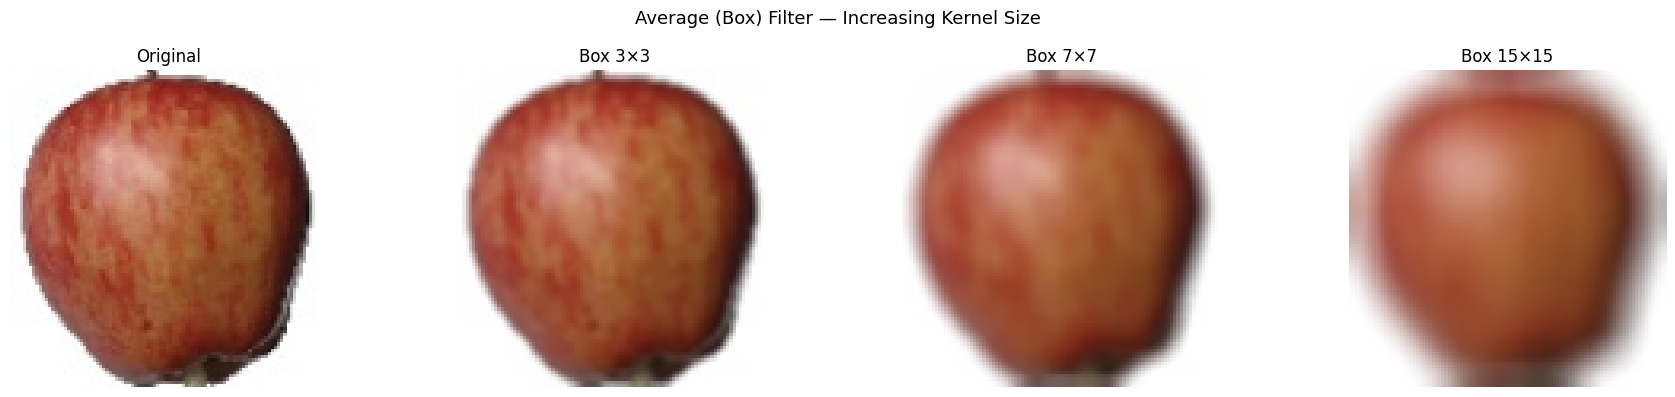

In [4]:
img = load_fruit("Apple Red 1")

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
axes[0].imshow(to_rgb(img))
axes[0].set_title("Original")

for i, k in enumerate([3, 7, 15]):
    kernel = np.ones((k, k), np.float32) / (k ** 2)
    filtered = cv2.filter2D(img, -1, kernel)
    axes[i + 1].imshow(to_rgb(filtered))
    axes[i + 1].set_title(f"Box {k}×{k}")

for ax in axes:
    ax.axis("off")
plt.suptitle("Average (Box) Filter — Increasing Kernel Size", fontsize=13)
plt.tight_layout()
plt.show()

### 1.2 Gaussian Filter

A Gaussian kernel assigns higher weight to the centre:

$$G(x,y) = \frac{1}{2\pi\sigma^2} \exp\!\left(-\frac{x^2 + y^2}{2\sigma^2}\right)$$

It is **separable**: a 2-D Gaussian is the outer product of two 1-D Gaussians, making it much faster to compute.

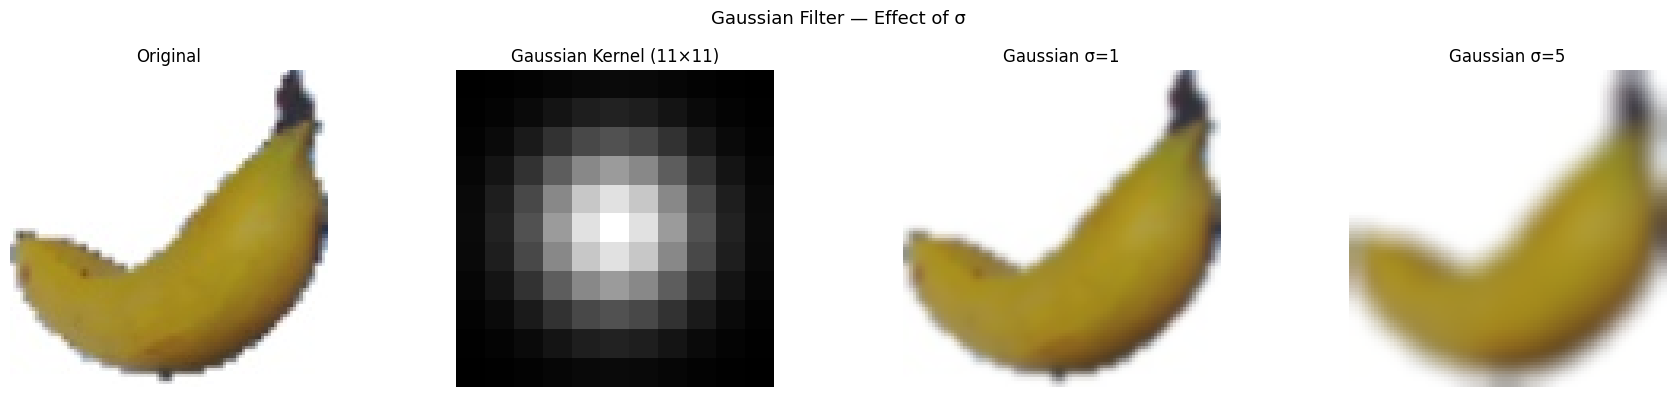

In [5]:
img = load_fruit("Banana 1")

k = 11
kernel_1d = cv2.getGaussianKernel(k, -1)
kernel_2d = kernel_1d @ kernel_1d.T

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
axes[0].imshow(to_rgb(img))
axes[0].set_title("Original")
axes[1].imshow(kernel_2d, cmap="gray")
axes[1].set_title(f"Gaussian Kernel ({k}×{k})")

for i, sigma in enumerate([1, 5]):
    blurred = cv2.GaussianBlur(img, (k, k), sigma)
    axes[i + 2].imshow(to_rgb(blurred))
    axes[i + 2].set_title(f"Gaussian σ={sigma}")

for ax in axes:
    ax.axis("off")
plt.suptitle("Gaussian Filter — Effect of σ", fontsize=13)
plt.tight_layout()
plt.show()

### 1.3 Border Handling

At image borders the kernel extends beyond the image. OpenCV supports several strategies:

| Mode | Behaviour | Pattern |
|------|-----------|---------|
| `BORDER_CONSTANT` | Pad with zeros | `000\|abcdefgh\|000` |
| `BORDER_REFLECT` | Mirror at edge | `cba\|abcdefgh\|hgf` |
| `BORDER_REPLICATE` | Repeat edge pixel | `aaa\|abcdefgh\|hhh` |
| `BORDER_WRAP` | Wrap around | `fgh\|abcdefgh\|abc` |

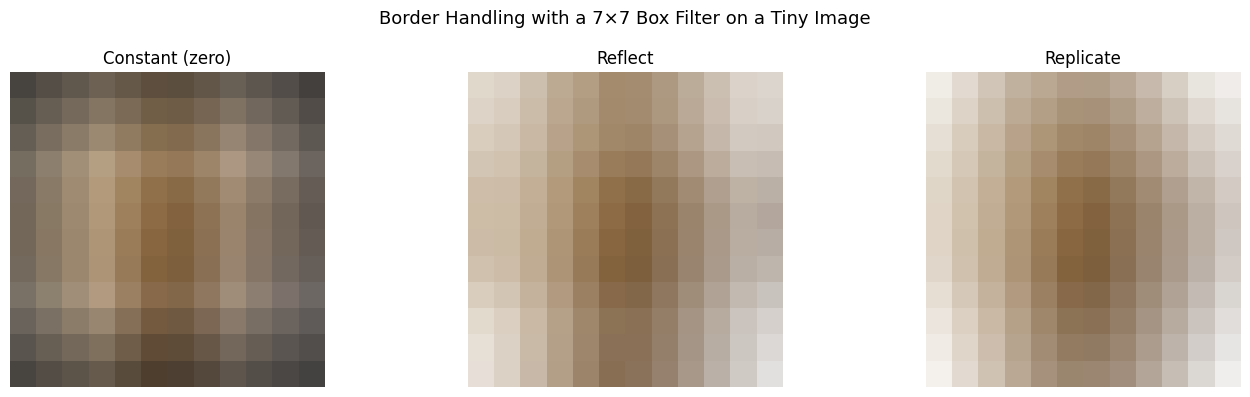

In [6]:
img_small = cv2.resize(load_fruit("Kiwi 1"), (12, 12))

k = 7
kernel = np.ones((k, k), np.float32) / (k ** 2)

modes = [
    ("Constant (zero)", cv2.BORDER_CONSTANT),
    ("Reflect", cv2.BORDER_REFLECT),
    ("Replicate", cv2.BORDER_REPLICATE),
]

fig, axes = plt.subplots(1, len(modes), figsize=(14, 4))
for ax, (title, mode) in zip(axes, modes):
    result = cv2.filter2D(img_small, -1, kernel, borderType=mode)
    ax.imshow(to_rgb(result), interpolation="nearest")
    ax.set_title(title)
    ax.axis("off")
plt.suptitle(f"Border Handling with a {k}×{k} Box Filter on a Tiny Image", fontsize=13)
plt.tight_layout()
plt.show()

## 2. The Fourier Transform

The **Discrete Fourier Transform (DFT)** decomposes an image into its frequency components — sinusoidal patterns of varying orientation and wavelength.

$$F(u,v) = \sum_{x=0}^{M-1} \sum_{y=0}^{N-1} f(x,y)\, e^{-j2\pi\left(\frac{ux}{M} + \frac{vy}{N}\right)}$$

- **Low frequencies** (near centre) = smooth / slow-changing content
- **High frequencies** (away from centre) = edges, textures, fine detail
- **Magnitude** $|F|$ tells us *how much* of each frequency is present
- **Phase** $\angle F$ encodes *where* structures are located

### 2.1 Computing the FFT of an Image

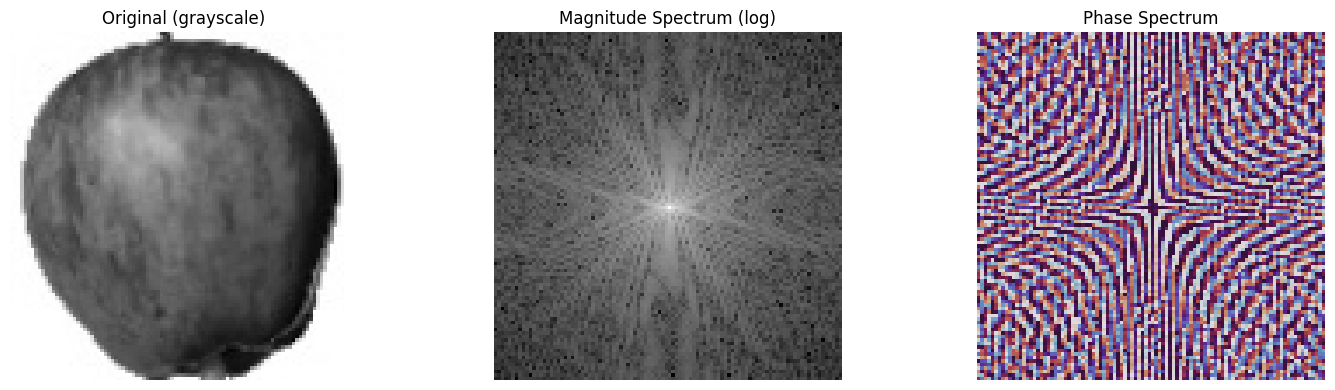

In [7]:
img = load_fruit("Apple Red 1")
gray = to_gray(img)

F = np.fft.fft2(gray)
Fshift = np.fft.fftshift(F)
magnitude = np.log1p(np.abs(Fshift))
phase = np.angle(Fshift)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].imshow(gray, cmap="gray")
axes[0].set_title("Original (grayscale)")
axes[1].imshow(magnitude, cmap="gray")
axes[1].set_title("Magnitude Spectrum (log)")
axes[2].imshow(phase, cmap="twilight")
axes[2].set_title("Phase Spectrum")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

### 2.2 Inverse FFT — Reconstructing the Image

The **inverse FFT** converts a spectrum back to the spatial domain. Since we haven’t modified anything, we should recover the original image exactly.

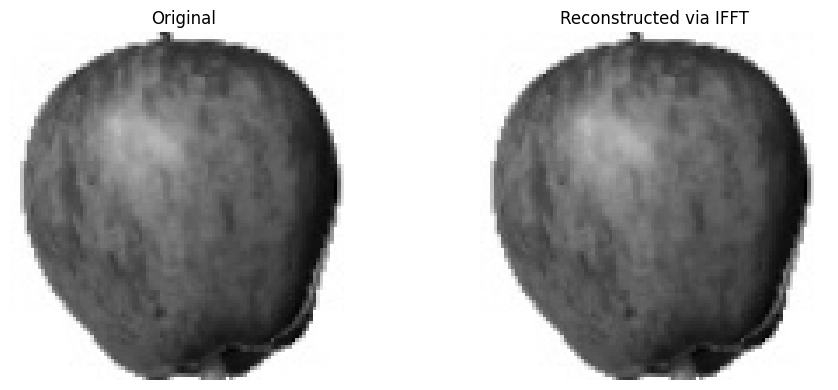

Max reconstruction error: 1.42e-13


In [8]:
reconstructed = np.fft.ifft2(F)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(gray, cmap="gray")
axes[0].set_title("Original")
axes[1].imshow(np.abs(reconstructed), cmap="gray")
axes[1].set_title("Reconstructed via IFFT")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

print(f"Max reconstruction error: {np.max(np.abs(gray - np.abs(reconstructed))):.2e}")

### 2.3 Building Intuition — Single Frequency Components

What does a single frequency look like? Let’s create spectra with only one non-zero entry and see the resulting image.

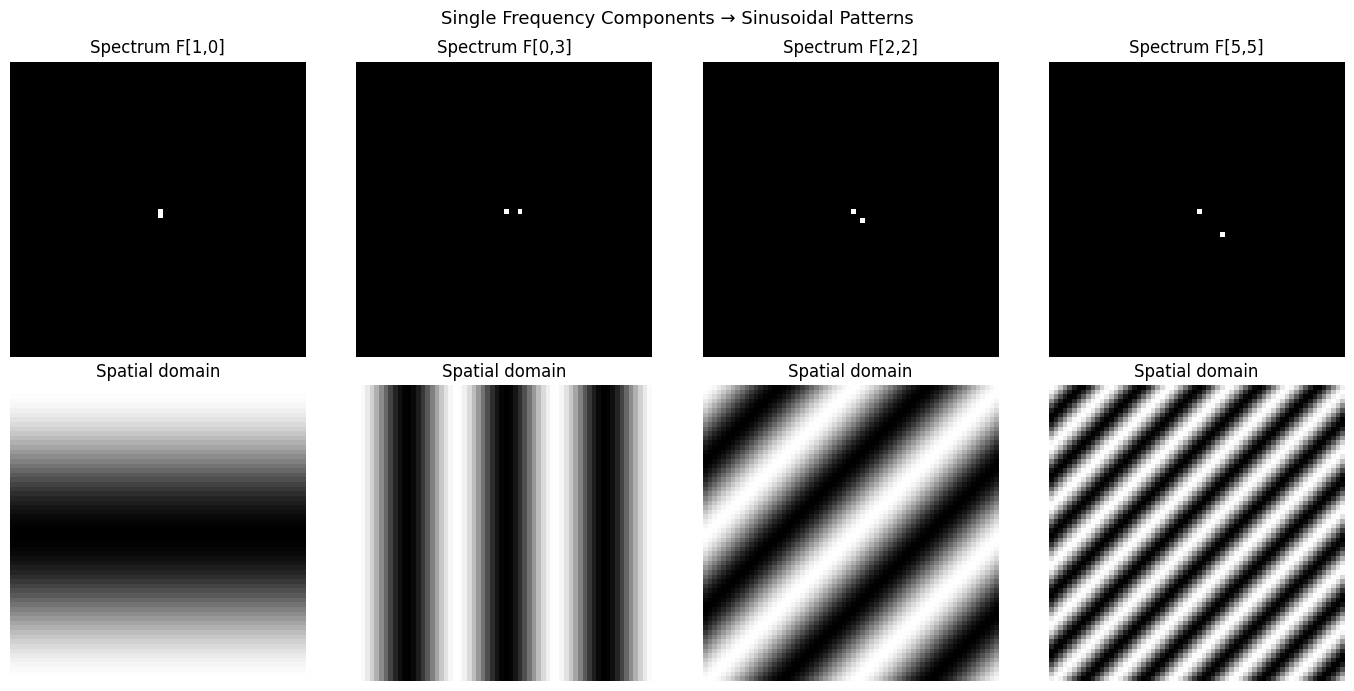

In [9]:
size = 64

freqs = [(1, 0), (0, 3), (2, 2), (5, 5)]

fig, axes = plt.subplots(2, len(freqs), figsize=(14, 7))
for col, (u, v) in enumerate(freqs):
    F = np.zeros((size, size), dtype=np.complex128)
    F[0, 0] = size * size  # DC component (mean gray)
    F[u, v] = size * size  # one frequency
    f = np.fft.ifft2(F)

    mag = np.log1p(np.abs(np.fft.fftshift(F)))
    axes[0, col].imshow(mag, cmap="gray")
    axes[0, col].set_title(f"Spectrum F[{u},{v}]")
    axes[0, col].axis("off")

    axes[1, col].imshow(np.real(f), cmap="gray")
    axes[1, col].set_title(f"Spatial domain")
    axes[1, col].axis("off")

axes[0, 0].set_ylabel("Frequency", fontsize=11)
axes[1, 0].set_ylabel("Spatial", fontsize=11)
plt.suptitle("Single Frequency Components → Sinusoidal Patterns", fontsize=13)
plt.tight_layout()
plt.show()

### 2.4 Low-Pass and High-Pass Filtering in the Frequency Domain

We can remove frequencies directly in the spectrum:
- **Low-pass**: keep only the centre (low frequencies) → smooth / blurry
- **High-pass**: remove the centre → edges and fine detail only

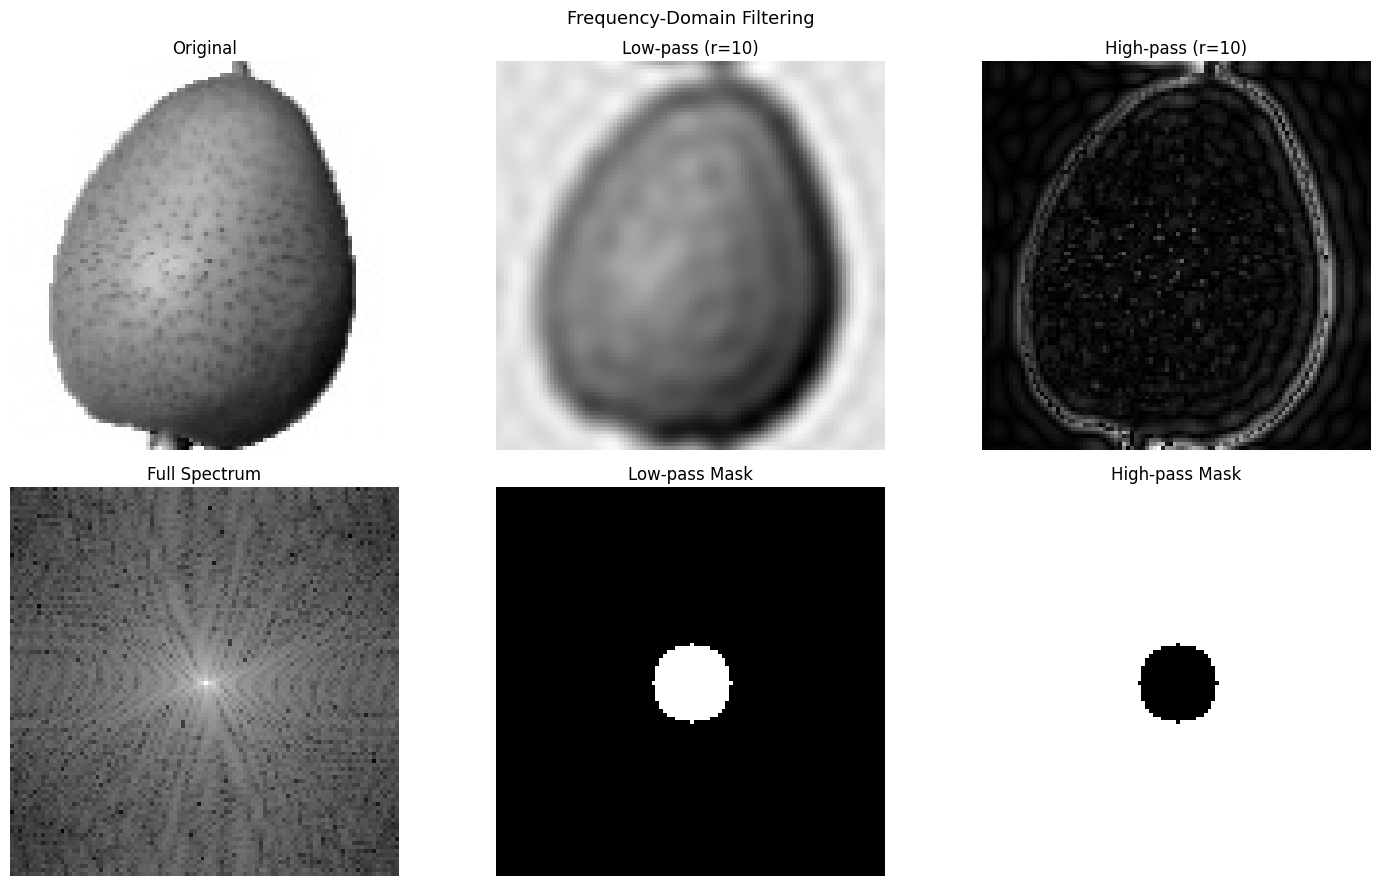

In [10]:
img = load_fruit("Pear 1")
gray = to_gray(img)

F = np.fft.fft2(gray)
Fshift = np.fft.fftshift(F)

rows, cols = gray.shape
crow, ccol = rows // 2, cols // 2

radius = 10

# Create circular masks
Y, X = np.ogrid[:rows, :cols]
dist = np.sqrt((X - ccol) ** 2 + (Y - crow) ** 2)
lp_mask = (dist <= radius).astype(np.float64)
hp_mask = (dist > radius).astype(np.float64)

# Apply masks
low_freq = np.fft.ifft2(np.fft.ifftshift(Fshift * lp_mask))
high_freq = np.fft.ifft2(np.fft.ifftshift(Fshift * hp_mask))

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

axes[0, 0].imshow(gray, cmap="gray")
axes[0, 0].set_title("Original")
axes[0, 1].imshow(np.abs(low_freq), cmap="gray")
axes[0, 1].set_title(f"Low-pass (r={radius})")
axes[0, 2].imshow(np.abs(high_freq), cmap="gray")
axes[0, 2].set_title(f"High-pass (r={radius})")

axes[1, 0].imshow(np.log1p(np.abs(Fshift)), cmap="gray")
axes[1, 0].set_title("Full Spectrum")
axes[1, 1].imshow(lp_mask, cmap="gray")
axes[1, 1].set_title("Low-pass Mask")
axes[1, 2].imshow(hp_mask, cmap="gray")
axes[1, 2].set_title("High-pass Mask")

for ax in axes.flat:
    ax.axis("off")
plt.suptitle("Frequency-Domain Filtering", fontsize=13)
plt.tight_layout()
plt.show()

### 2.5 The Convolution Theorem

Convolution in the spatial domain equals **point-wise multiplication** in the frequency domain:

$$f * h = \mathcal{F}^{-1}\{F \cdot H\}$$

This means applying a Gaussian blur is the same as multiplying the spectrum by the Gaussian’s frequency response.

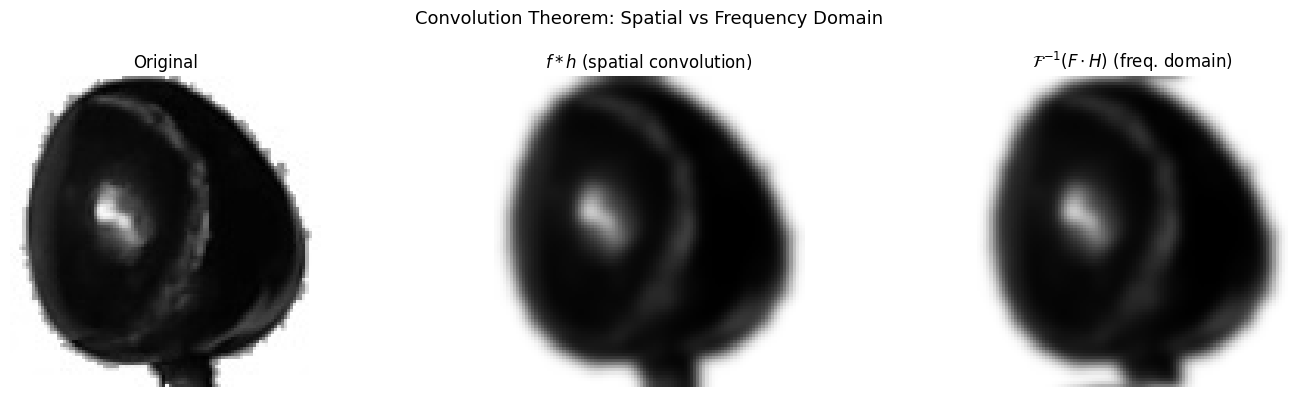

In [11]:
img = load_fruit("Cherry 1")
gray = to_gray(img).astype(np.float64)

rows, cols = gray.shape

k_size = 11
kh = k_size // 2
kernel_1d = cv2.getGaussianKernel(k_size, -1)
kernel_small = kernel_1d @ kernel_1d.T

# Pad kernel to image size and place at centre
kernel_padded = np.zeros_like(gray)
crow, ccol = rows // 2, cols // 2
kernel_padded[crow - kh:crow + kh + 1, ccol - kh:ccol + kh + 1] = kernel_small

# Spatial convolution
spatial_result = cv2.filter2D(gray, -1, kernel_padded)

# Frequency-domain multiplication
F = np.fft.fft2(gray)
K = np.fft.fft2(kernel_padded)
freq_result = np.fft.ifftshift(np.fft.ifft2(F * K))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].imshow(gray, cmap="gray")
axes[0].set_title("Original")
axes[1].imshow(np.abs(spatial_result), cmap="gray")
axes[1].set_title(r"$f * h$ (spatial convolution)")
axes[2].imshow(np.abs(freq_result), cmap="gray")
axes[2].set_title(r"$\mathcal{F}^{-1}(F \cdot H)$ (freq. domain)")
for ax in axes:
    ax.axis("off")
plt.suptitle("Convolution Theorem: Spatial vs Frequency Domain", fontsize=13)
plt.tight_layout()
plt.show()

### 2.6 Importance of Magnitude vs Phase

An interesting experiment: what carries more perceptual information — the **magnitude** or the **phase** of the spectrum? Let’s swap them between two fruit images.

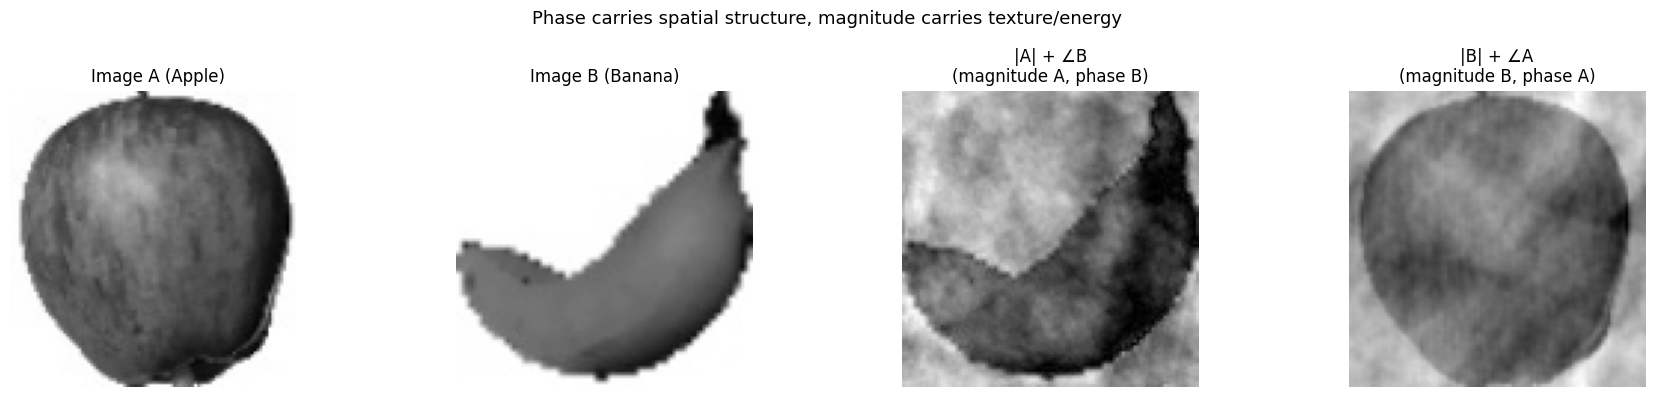

In [12]:
img_a = to_gray(load_fruit("Apple Red 1"))
img_b = to_gray(load_fruit("Banana 1"))

F_a = np.fft.fft2(img_a)
F_b = np.fft.fft2(img_b)

mag_a, phase_a = np.abs(F_a), np.angle(F_a)
mag_b, phase_b = np.abs(F_b), np.angle(F_b)

# Combine magnitude of A with phase of B (and vice versa)
combo_mag_a_phase_b = np.fft.ifft2(mag_a * np.exp(1j * phase_b))
combo_mag_b_phase_a = np.fft.ifft2(mag_b * np.exp(1j * phase_a))

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
axes[0].imshow(img_a, cmap="gray")
axes[0].set_title("Image A (Apple)")
axes[1].imshow(img_b, cmap="gray")
axes[1].set_title("Image B (Banana)")
axes[2].imshow(np.abs(combo_mag_a_phase_b), cmap="gray")
axes[2].set_title("|A| + ∠B\n(magnitude A, phase B)")
axes[3].imshow(np.abs(combo_mag_b_phase_a), cmap="gray")
axes[3].set_title("|B| + ∠A\n(magnitude B, phase A)")
for ax in axes:
    ax.axis("off")
plt.suptitle("Phase carries spatial structure, magnitude carries texture/energy", fontsize=13)
plt.tight_layout()
plt.show()

## 3. Hybrid Images

**Hybrid images** exploit the fact that we perceive **high frequencies up close** and **low frequencies from afar**.

The idea (from [Oliva, Torralba & Schyns, 2006](http://olivalab.mit.edu/publications/OlivaTorralb_Hybrid_Siggraph06.pdf)):
1. Take the **low-frequency** content of image A (Gaussian blur)
2. Take the **high-frequency** content of image B (original minus its blur)
3. **Add** them together

Close up you see image B (edges); from a distance (or squinting) you see image A.

In [13]:
def make_hybrid(img_low_src, img_high_src, sigma_low=10, sigma_high=10):
    """Create a hybrid image from two source images.

    Args:
        img_low_src: Image whose low frequencies will be used (grayscale float64).
        img_high_src: Image whose high frequencies will be used (grayscale float64).
        sigma_low: Gaussian sigma for extracting low frequencies.
        sigma_high: Gaussian sigma for extracting high frequencies.

    Returns:
        Tuple of (low_freq, high_freq, hybrid).
    """
    ksize = int(6 * max(sigma_low, sigma_high)) | 1  # ensure odd
    low = cv2.GaussianBlur(img_low_src, (ksize, ksize), sigma_low)
    high = img_high_src - cv2.GaussianBlur(img_high_src, (ksize, ksize), sigma_high)
    hybrid = low + high
    return low, high, hybrid

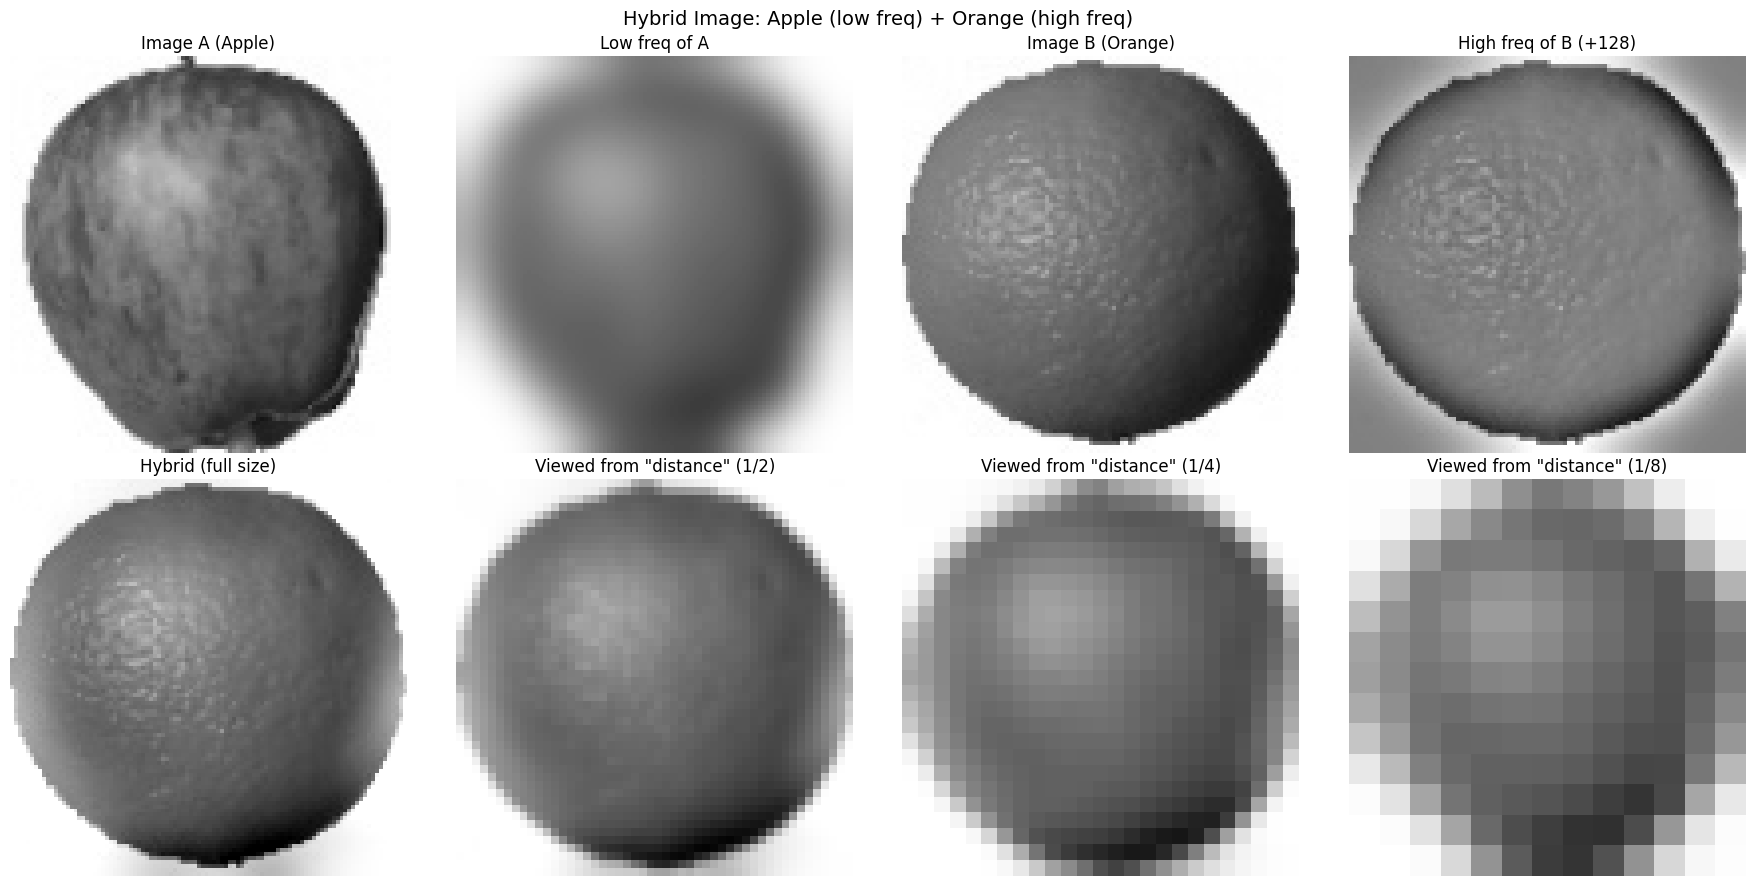

In [14]:
img_a = to_gray(load_fruit("Apple Red 1")).astype(np.float64)
img_b = to_gray(load_fruit("Orange 1")).astype(np.float64)

low, high, hybrid = make_hybrid(img_a, img_b, sigma_low=6, sigma_high=6)

fig, axes = plt.subplots(2, 4, figsize=(18, 9))

axes[0, 0].imshow(img_a, cmap="gray", vmin=0, vmax=255)
axes[0, 0].set_title("Image A (Apple)")
axes[0, 1].imshow(low, cmap="gray", vmin=0, vmax=255)
axes[0, 1].set_title("Low freq of A")
axes[0, 2].imshow(img_b, cmap="gray", vmin=0, vmax=255)
axes[0, 2].set_title("Image B (Orange)")
axes[0, 3].imshow(high + 128, cmap="gray", vmin=0, vmax=255)
axes[0, 3].set_title("High freq of B (+128)")

axes[1, 0].imshow(np.clip(hybrid, 0, 255), cmap="gray", vmin=0, vmax=255)
axes[1, 0].set_title("Hybrid (full size)")

# Simulate viewing from a distance by progressively downscaling
small = np.clip(hybrid, 0, 255).astype(np.uint8)
for i in range(1, 4):
    small = cv2.pyrDown(small)
    axes[1, i].imshow(small, cmap="gray", vmin=0, vmax=255)
    axes[1, i].set_title(f"Viewed from \"distance\" (1/{2**i})")

for ax in axes.flat:
    ax.axis("off")
plt.suptitle("Hybrid Image: Apple (low freq) + Orange (high freq)", fontsize=14)
plt.tight_layout()
plt.show()

### 3.1 Hybrid Images in the Frequency Domain

Let’s visualise what happens in the frequency domain when we create a hybrid image.

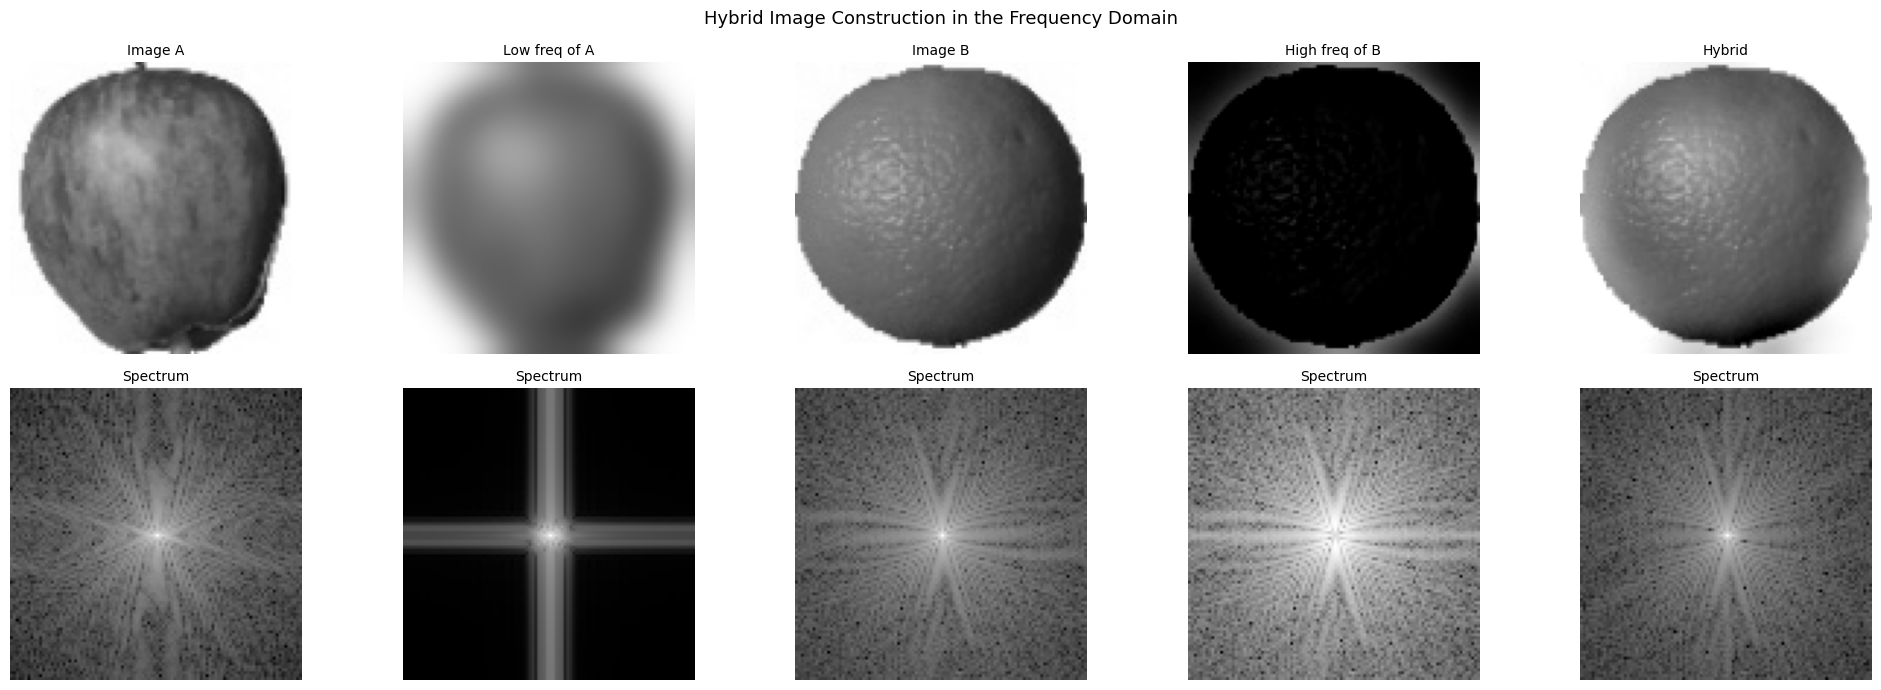

In [15]:
low, high, hybrid = make_hybrid(img_a, img_b, sigma_low=6, sigma_high=6)

spectra = [
    ("Image A", img_a),
    ("Low freq of A", low),
    ("Image B", img_b),
    ("High freq of B", high),
    ("Hybrid", np.clip(hybrid, 0, 255)),
]

fig, axes = plt.subplots(2, len(spectra), figsize=(20, 7))
for col, (title, im) in enumerate(spectra):
    axes[0, col].imshow(im, cmap="gray", vmin=0, vmax=255)
    axes[0, col].set_title(title, fontsize=10)
    axes[0, col].axis("off")

    F = np.fft.fftshift(np.fft.fft2(im))
    axes[1, col].imshow(np.log1p(np.abs(F)), cmap="gray")
    axes[1, col].set_title("Spectrum", fontsize=10)
    axes[1, col].axis("off")

axes[0, 0].set_ylabel("Spatial", fontsize=11)
axes[1, 0].set_ylabel("Frequency", fontsize=11)
plt.suptitle("Hybrid Image Construction in the Frequency Domain", fontsize=13)
plt.tight_layout()
plt.show()

## ✏️ Exercises

### Exercise 1: Implement Your Own Filter Operation

Implement a **2-D convolution** from scratch — **without** using `cv2.filter2D` or any library filtering function.

**Tasks:**

1. Load a fruit image (e.g. `"Apple Red 1"`) and convert it to **grayscale**.
2. Implement a function `my_filter2d(image, kernel)` that:
   - Iterates over every pixel (you may use nested loops or NumPy slicing)
   - Computes the weighted sum of the pixel’s neighbourhood using `kernel`
   - Ignores the border (crop the output by `k//2` pixels on each side)
3. Apply a $3 \times 3$ **box kernel** (all weights $= 1/9$) and compare your result to `cv2.filter2D`.
4. Apply a $5 \times 5$ **Gaussian kernel** (use `cv2.getGaussianKernel` to build the 2-D kernel, then pass it to **your** function).

**Verification:** compute the **Mean Squared Error (MSE)** between your output and the OpenCV reference — it should be very close to zero.

**Hint:** for each output pixel $(x, y)$, sum `image[x:x+kh, y:y+kw] * kernel`.

1.5492455566454355


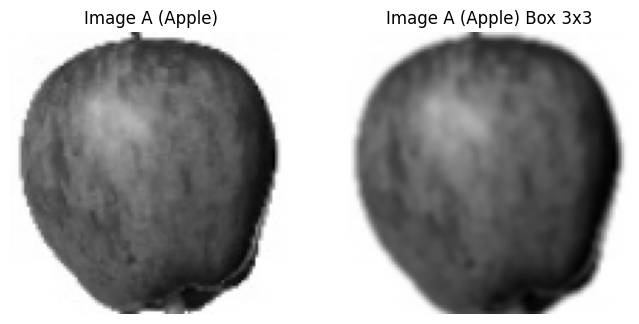

In [16]:
# Your code here
from matplotlib.axes import Axes


def MSE(A, B):
    return ((A.astype(np.float64) - B.astype(np.float64)) ** 2).mean()

def my_filter2d(image, kernel):
    """Apply 2-D convolution (no border handling — crop output)."""
    kh, kw = kernel.shape
    # pad_h, pad_w = kh // 2, kw // 2
    out = np.zeros(
        (image.shape[0] - kh, image.shape[1] - kw),
        dtype=np.float64
    )
    # TODO: fill in the convolution loop
    for i in range(out.size):
        x = i % out.shape[0]
        y =  i // out.shape[1]
        out[x, y] += np.sum(image[x:x+kh, y:y+kw] * kernel)
    return out

img_a = to_gray(load_fruit("Apple Red 1")).astype(np.float64)
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes:list[Axes] = axes
axes[0].imshow(img_a, cmap="gray")
axes[0].set_title("Image A (Apple)")
axes[0].axis("off")

k = 3
kernel = np.ones((k, k), np.float32) / (k ** 2)
filterd = my_filter2d(img_a, kernel)
axes[1].imshow(filterd, cmap="gray")
axes[1].set_title("Image A (Apple) Box 3x3")
axes[1].axis("off")
print(MSE(cv2.GaussianBlur(img_a,(k,k), 1)[1:98, 1:98], filterd))

(np.float64(-0.5), np.float64(98.5), np.float64(94.5), np.float64(-0.5))

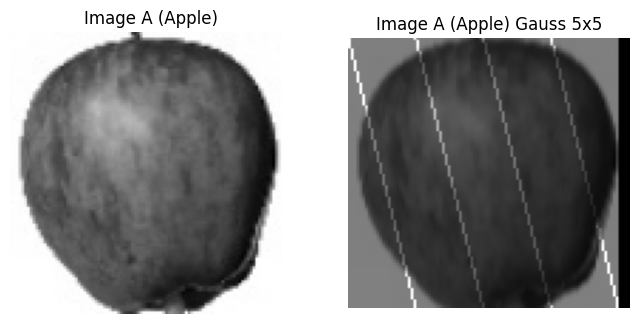

In [17]:
img_a = to_gray(load_fruit("Apple Red 1")).astype(np.float64)
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes:list[Axes] = axes
axes[0].imshow(img_a, cmap="gray")
axes[0].set_title("Image A (Apple)")
axes[0].axis("off")

k = 3
kernel = cv2.getGaussianKernel(5, 1)
filterd = my_filter2d(img_a, kernel)
axes[1].imshow(filterd, cmap="gray")
axes[1].set_title("Image A (Apple) Gauss 5x5")
axes[1].axis("off")

### Exercise 2: Drawing in the Frequency Domain

Create images by **painting directly in the frequency domain** and converting back with the inverse FFT.

**Tasks:**

1. **Checkerboard:** Create an $8 \times 8$ checkerboard pattern by setting the right frequency bins. *Hint:* a checkerboard is a diagonal sinusoid — think about which $(u, v)$ entry to set.
2. **Horizontal stripes:** Create a $64 \times 64$ image with horizontal stripes of a chosen wavelength.
3. **Concentric rings:** Create a spectrum that produces concentric circles or rings in the spatial domain. *Hint:* a ring in frequency space produces a specific spatial pattern.
4. **Combine & experiment:** Add multiple frequency components together and observe the result. Can you create a plaid pattern? A star burst?

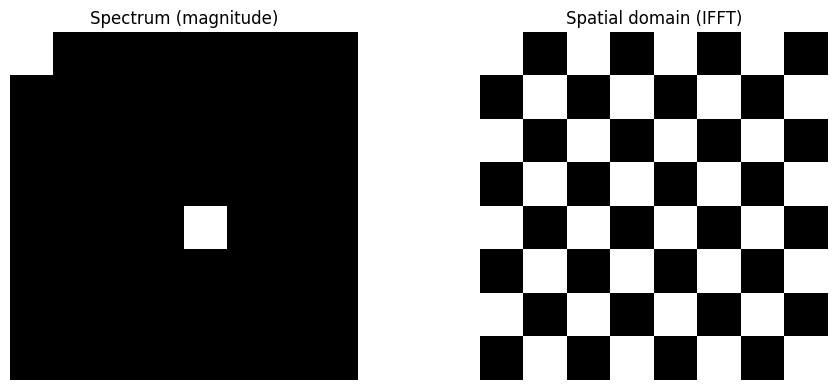

In [18]:
# Your code here
size = 8
F = np.zeros((size, size), dtype=np.complex128)
F[0, 0] = size * size  # DC component (mean brightness)

# TODO: set additional frequency bins
# e.g., F[u, v] = amplitude
F[4, 4] = size*size # 4,4, because its the max frequency for size 8 and a diagnoal

f = np.fft.ifft2(F)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(np.abs(np.fft.fftshift(F)), cmap="gray")
axes[0].set_title("Spectrum (magnitude)")
axes[1].imshow(np.real(f), cmap="gray")
axes[1].set_title("Spatial domain (IFFT)")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

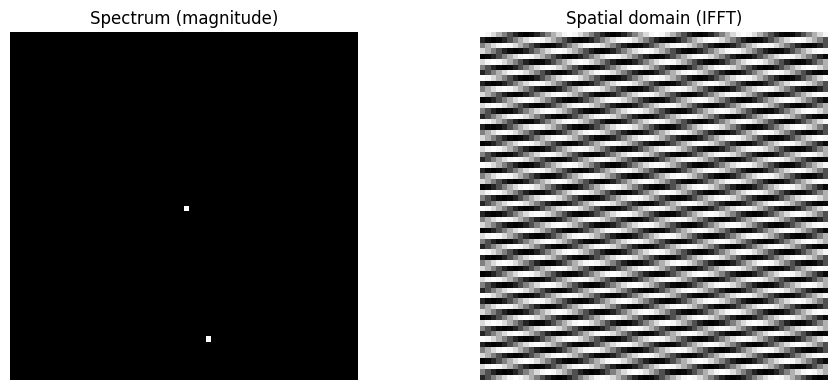

In [19]:
# Your code here
size = 64
F = np.zeros((size, size), dtype=np.complex128)
F[0, 0] = size * size  # DC component (mean brightness)

# TODO: set additional frequency bins
# e.g., F[u, v] = amplitude
F[24, 4] = size*size 
# F[32, 32] = size*size
f = np.fft.ifft2(F)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(np.abs(np.fft.fftshift(F)), cmap="gray")
axes[0].set_title("Spectrum (magnitude)")
axes[1].imshow(np.real(f), cmap="gray")
axes[1].set_title("Spatial domain (IFFT)")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

### Exercise 3: Hybrid Images with Fruits

Create your own hybrid images by combining the low frequencies of one fruit with the high frequencies of another.

**Tasks:**

1. Pick **3 pairs** of visually distinct fruits from the Fruits-360 dataset (e.g., Apple/Orange, Banana/Kiwi, Strawberry/Lemon).
2. For each pair, use the `make_hybrid` function (defined above) to create a hybrid image.
3. **Experiment with σ:** For one pair, create a grid of hybrids with different `sigma_low` and `sigma_high` values (e.g., 3, 6, 10). Show the results in a subplot grid — which σ combination produces the strongest illusion?
4. **Simulate distance:** For your best hybrid, show a “distance strip” — progressively downsample the image (using `cv2.pyrDown`) to simulate viewing from far away. At which downscale level does the perceived image switch?
5. **Bonus — Colour hybrids:** Extend the approach to work on colour images. Apply the low-pass / high-pass decomposition **per channel** (B, G, R). Does colour improve the illusion?

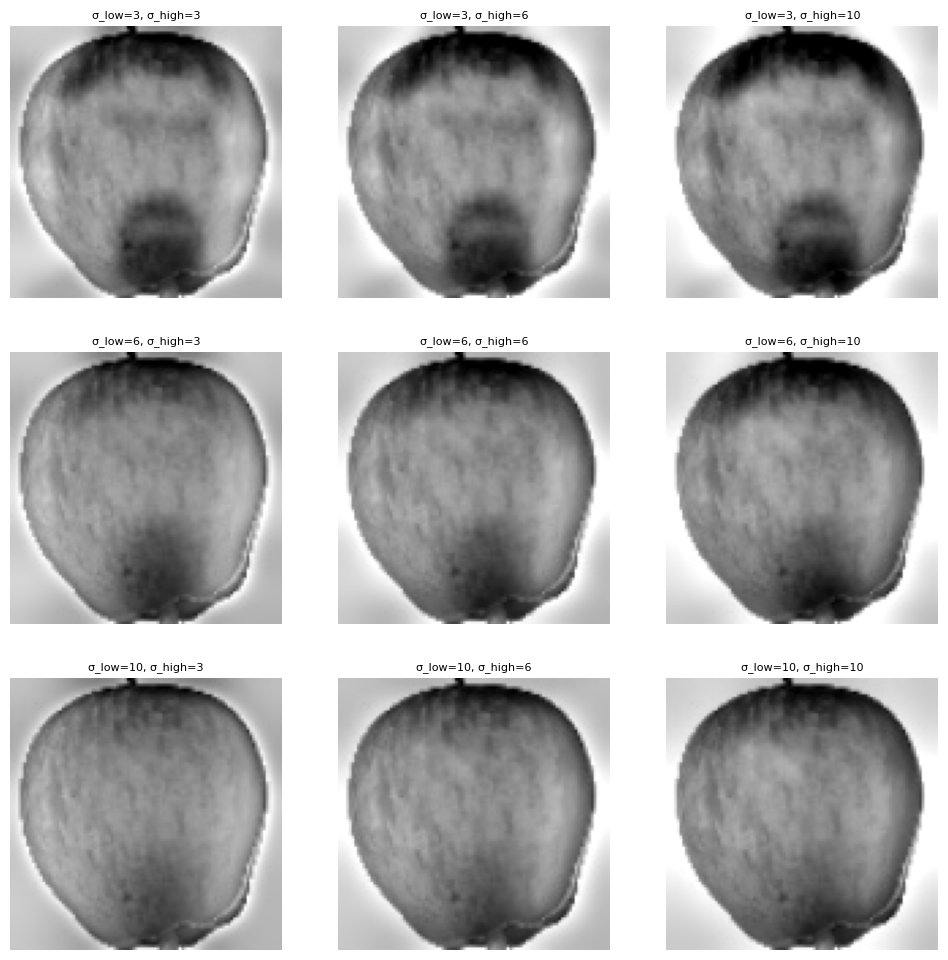

In [48]:
# Your code here
# Load a pair
omni = to_gray(cv2.imread("./fruits-360-100x100/omniman_small.png")).astype(np.float64)
apple = to_gray(load_fruit("Apple Red 1")).astype(np.float64)
corn = to_gray(load_fruit("Corn Husk 1")).astype(np.float64)

# Create hybrid
low, high, hybrid = make_hybrid(omni, corn, sigma_low=0, sigma_high=10)

# Sigma grid
sigmas = [3, 6, 10]
fig, axes = plt.subplots(len(sigmas), len(sigmas), figsize=(12, 12))
for i, s_low in enumerate(sigmas):
    for j, s_high in enumerate(sigmas):
        _, _, h = make_hybrid(omni, apple, sigma_low=s_low, sigma_high=s_high)
        axes[i, j].imshow(np.clip(h, 0, 255), cmap="gray")
        axes[i, j].set_title(f"σ_low={s_low}, σ_high={s_high}", fontsize=8)
        axes[i, j].axis("off")

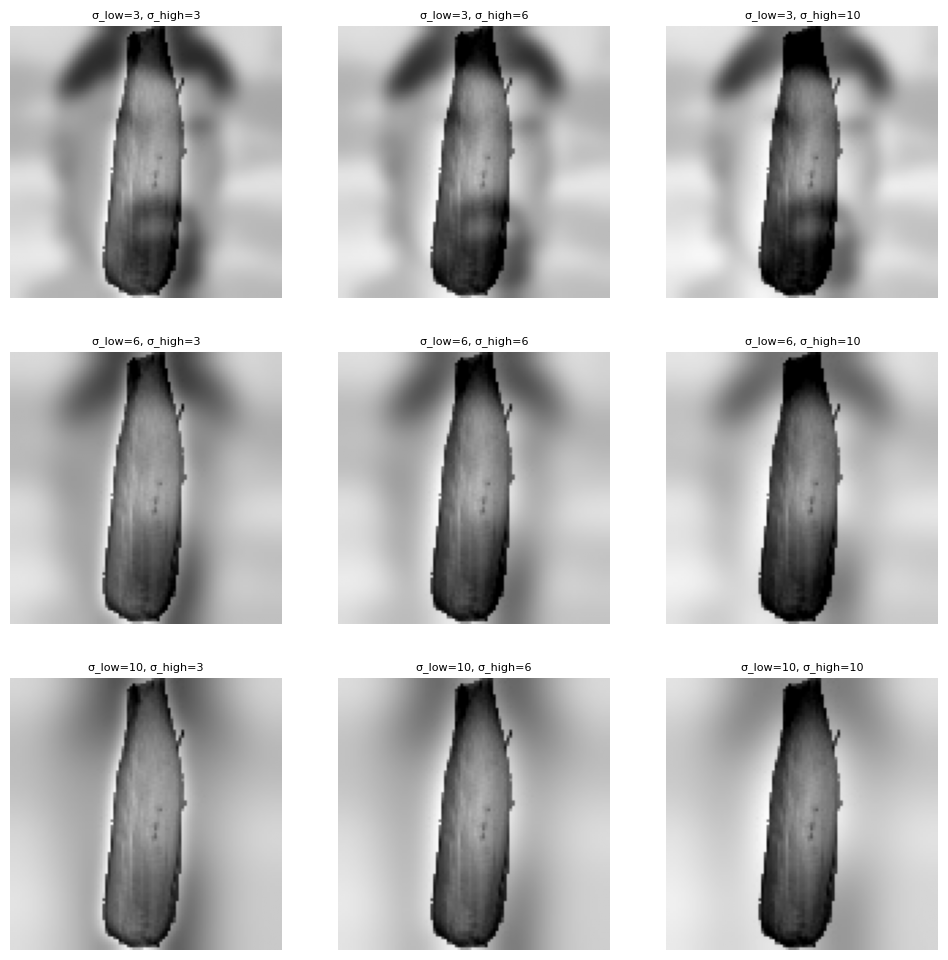

In [50]:
fig, axes = plt.subplots(len(sigmas), len(sigmas), figsize=(12, 12))
for i, s_low in enumerate(sigmas):
    for j, s_high in enumerate(sigmas):
        _, _, h = make_hybrid(omni, corn, sigma_low=s_low, sigma_high=s_high)
        axes[i, j].imshow(np.clip(h, 0, 255), cmap="gray")
        axes[i, j].set_title(f"σ_low={s_low}, σ_high={s_high}", fontsize=8)
        axes[i, j].axis("off")

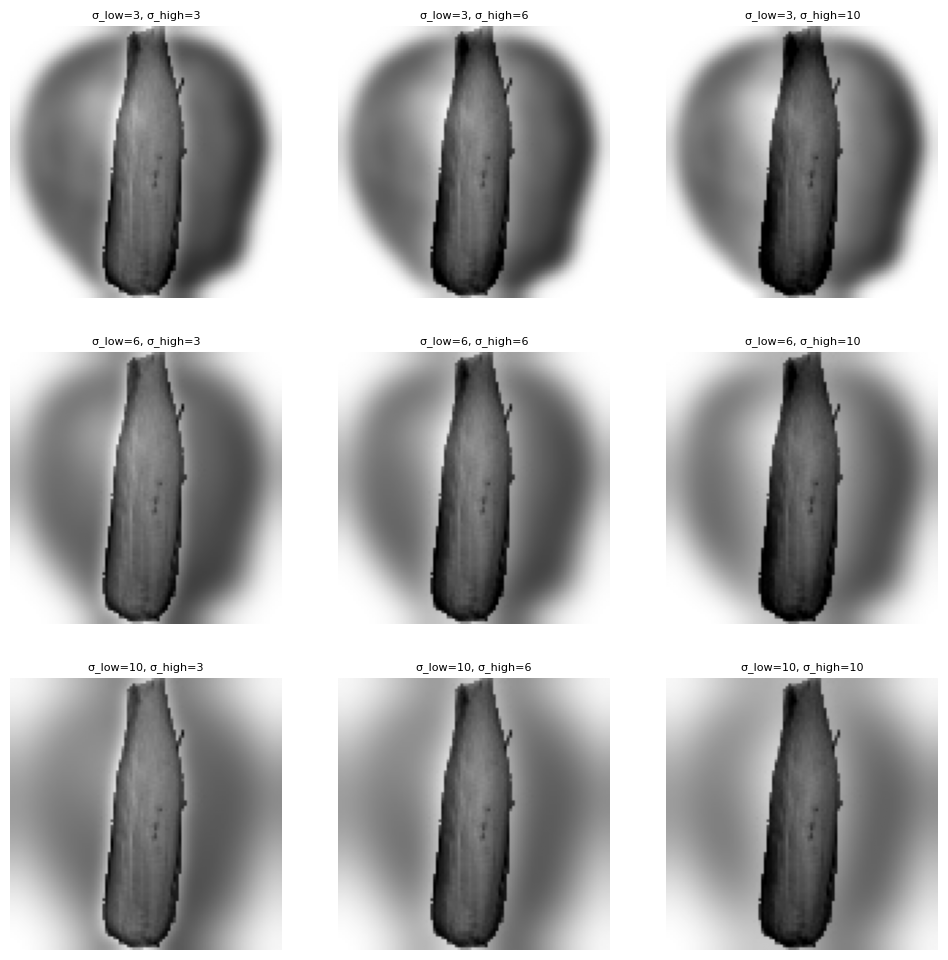

In [49]:
fig, axes = plt.subplots(len(sigmas), len(sigmas), figsize=(12, 12))
for i, s_low in enumerate(sigmas):
    for j, s_high in enumerate(sigmas):
        _, _, h = make_hybrid(apple, corn, sigma_low=s_low, sigma_high=s_high)
        axes[i, j].imshow(np.clip(h, 0, 255), cmap="gray")
        axes[i, j].set_title(f"σ_low={s_low}, σ_high={s_high}", fontsize=8)
        axes[i, j].axis("off")

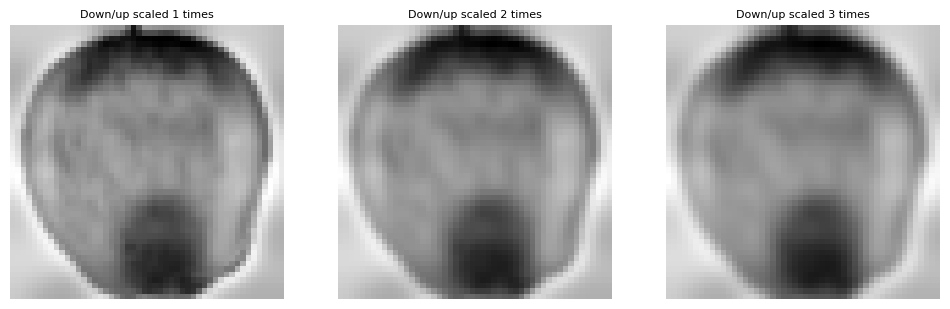

In [73]:
# Sigma grid
from copy import deepcopy

_, _, h = make_hybrid(omni, apple, sigma_low=4, sigma_high=4)
fig, axes = plt.subplots(1, 3, figsize=(12, 12))
for i in range(3):
    h = cv2.pyrDown(h)
    axes[i].imshow(np.clip(h, 0, 255), cmap="gray")
    axes[i].set_title(f"Down/up scaled {i+1} times", fontsize=8)
    axes[i].axis("off")
    h = cv2.pyrUp(h)

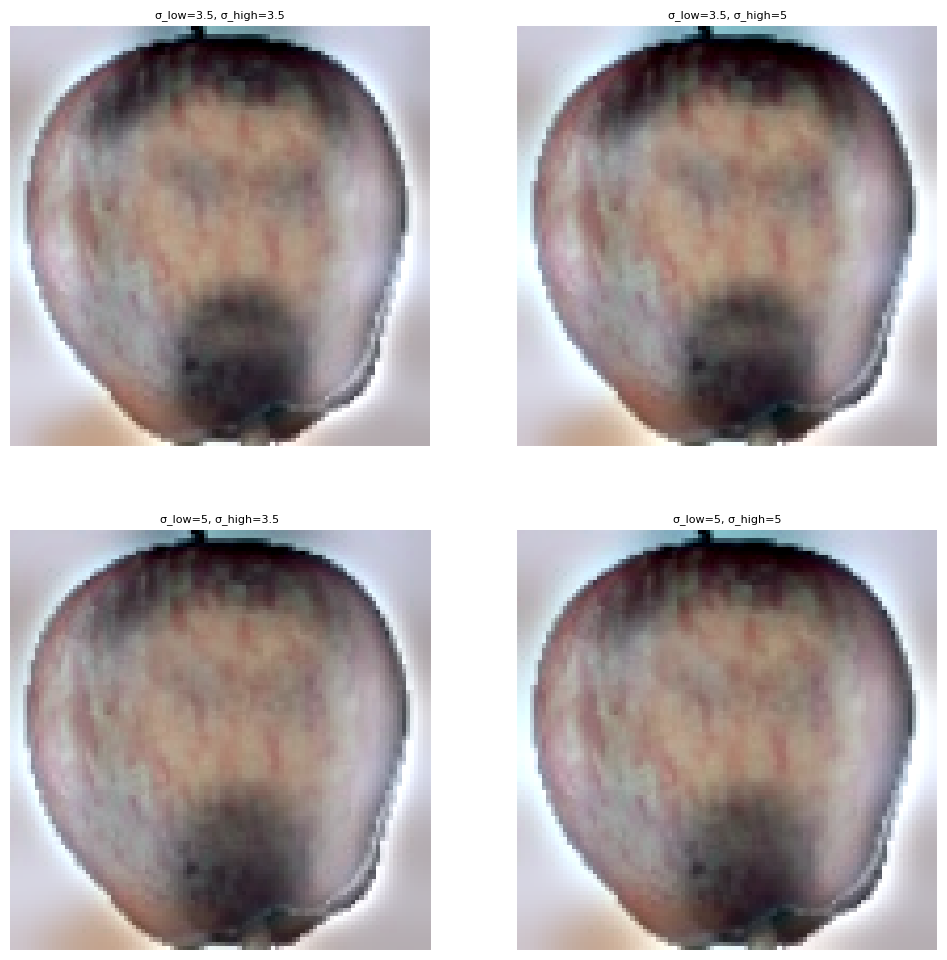

In [88]:

omni = to_rgb(cv2.imread("./fruits-360-100x100/omniman_small.png")).astype(np.float64)
apple = to_rgb(load_fruit("Apple Red 1")).astype(np.float64)

# Sigma grid
sigmas = [3.5, 5]
axes: list[list[Axes]]
fig, axes = plt.subplots(len(sigmas), len(sigmas), figsize=(12, 12))
for i, s_low in enumerate(sigmas):
    for j, s_high in enumerate(sigmas):
        _, _, h = make_hybrid(omni, apple, sigma_low=s_low, sigma_high=s_high)
        axes[i][j].imshow(np.clip(h/255, 0, 1))
        axes[i][j].set_title(f"σ_low={s_low}, σ_high={s_high}", fontsize=8)
        axes[i][j].axis("off")